## Rice Downregulated Gene Group (3Di + AA Goto-Smith-Waterman alignment method result)

- Analysis using protein sequences used for structure prediction in the AlphaFold Structure database
- [alphafold/sequences.fasta](https://ftp.ebi.ac.uk/pub/databases/alphafold/sequences.fasta)

&nbsp;

- Integrate rice gene ID and gene expression indicator HN-score information with Foldseek results

In [1]:
import datetime
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from upsetplot import UpSet, from_contents
from matplotlib.patches import Patch
from IPython.display import display

In [2]:
rice_idmapping_file_path = "../Data/12_rice_uniprot_idmapping/rice_down_idmapping_all.tsv"
rice_hnscore_file_path = "../Data/07_extract_gene/HN5_genelist_rice_2505/HN5_genes_down_rice.tsv"

foldseek_result_file_path = "../Data/14_foldseek_result/evalue01/foldseek_output_uniprot_rice_down_all_evalue01.tsv"
main_target_species = 9606
# output_tsv_path = "../Data/14_foldseek_result/foldseek_output_uniprot_rice_down_9606_modified.tsv"

In [3]:
# re-execution for doctor thesis
VERSION = datetime.datetime.now().strftime("%Y%m%d")
print(f"Execute Date: {VERSION}")

Execute Date: 20260924


In [4]:
rice_idmapping = pl.read_csv(
    rice_idmapping_file_path,
    separator='\t'
)

rice_hnscore = pl.read_csv(
    rice_hnscore_file_path,
    separator='\t'
).select(
    "From",
    "HN5"
)

rice_idmapping_hnscore = rice_hnscore.join(
    rice_idmapping,
    on="From",
    how="left",
    coalesce=True,
    validate="1:m"
).sort(
    by=["HN5"],
    descending=[True]
)

# display(rice_idmapping)
display(rice_idmapping_hnscore)

From,HN5,UniProt Accession
str,i64,str
"""Os01g0192900""",-40,"""A0A0P0UZP7"""
"""Os01g0192900""",-40,"""O24220"""
"""Os01g0192900""",-40,"""Q9FU17"""
"""Os01g0248701""",-40,"""A0A979HJQ7"""
"""Os01g0248701""",-40,"""C7IXE8"""
…,…,…
"""Os03g0307200""",-180,"""Q10MI9"""
"""Os07g0142200""",-186,"""A0A0P0X2Q0"""
"""Os07g0142200""",-186,"""Q8H4K4"""


In [5]:
foldseek_result_all = pl.read_csv(
    foldseek_result_file_path,
    separator='\t'
).rename(
    {
        "query" : "UniProt Accession",
        "target" : "foldseek hit"
    }
).with_columns(
    (pl.col("UniProt Accession").str.extract(r"AF-(.*?)-F1", 1).alias("UniProt Accession")), # "?" means non-greedy
    (pl.col("foldseek hit").str.extract(r"AF-(.*?)-F1", 1).alias("foldseek hit"))
)

foldseek_result_all_v2 = rice_idmapping_hnscore.join(   
    foldseek_result_all,
    on="UniProt Accession",
    how="left",
    coalesce=True,
    validate="1:m"
)

foldseek_result_all_hit = foldseek_result_all_v2.filter(
    pl.col("foldseek hit").is_not_null()
)

display(foldseek_result_all_hit)

From,HN5,UniProt Accession,foldseek hit,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,qcov,tcov,lddt,qtmscore,ttmscore,alntmscore,rmsd,taxid,taxname,taxlineage,qaln,taln,mismatch,lddtfull
str,i64,str,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,i64,str,str,str,str,i64,str
"""Os01g0192900""",-40,"""A0A0P0UZP7""","""A0A0E0MSJ8""",1.1550e-81,1.0,0,99.1,0.991,457,73,533,533,1,461,461,461,0.865,1.0,0.9605,0.8406,0.9711,0.9711,4.481,4529,"""Oryza rufipogon""","""-_cellular organisms;d_Eukaryo…","""MGGKLLPAAAFAGSAPPLSQVATSAAHGED…","""MGGKLLPAAAFAGSAPPLSQVATSAAHGED…",4,"""0.312,0.500,0.591,0.705,0.708,…"
"""Os01g0192900""",-40,"""A0A0P0UZP7""","""A0A1D6MHP0""",2.9770e-74,1.0,2,82.4,0.824,381,73,529,533,1,461,462,462,0.857,0.998,0.9418,0.8308,0.9578,0.9578,5.371,4577,"""Zea mays""","""-_cellular organisms;d_Eukaryo…","""MGGKLLPAAA-----FAGSAPPLSQVATSA…","""MGGKLLLGASQSRHAHAVASPPLSKVATSG…",75,"""0.208,0.409,0.409,0.545,0.500,…"
"""Os01g0192900""",-40,"""A0A0P0UZP7""","""A0A3L6FCW7""",2.7960e-73,1.0,2,82.4,0.824,381,73,529,533,1,461,462,462,0.857,0.998,0.9328,0.8264,0.9525,0.9525,5.899,4577,"""Zea mays""","""-_cellular organisms;d_Eukaryo…","""MGGKLLPAAA-----FAGSAPPLSQVATSA…","""MGGKLLLGASQSRHAHAVASPPLSKVATSG…",75,"""0.208,0.477,0.523,0.636,0.562,…"
"""Os01g0192900""",-40,"""A0A0P0UZP7""","""A0A0E0PIM6""",3.2680e-67,1.0,6,74.6,0.746,341,78,524,533,1,451,452,457,0.839,0.998,0.9228,0.8114,0.9555,0.9555,1.748,4529,"""Oryza rufipogon""","""-_cellular organisms;d_Eukaryo…","""LPAAAFAGSAPPLSQVATSAAHGEDSPYFA…","""MVGRMLSSPEPTLSTMAMSAAHGEDSPYFA…",100,"""0.425,0.525,0.625,0.700,0.850,…"
"""Os01g0192900""",-40,"""A0A0P0UZP7""","""A0A0E0PKQ1""",1.7400e-68,1.0,6,78.4,0.784,367,73,522,533,1,468,496,468,0.844,0.944,0.9146,0.813,0.873,0.873,5.005,4529,"""Oryza rufipogon""","""-_cellular organisms;d_Eukaryo…","""MGGKLLP-AAAFAGSAPPLSQVATSAAHGE…","""MGVKLLADGCAGASSSPALSRVATSAAHGE…",83,"""0.271,0.523,0.545,0.545,0.500,…"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Os03g0307300""",-204,"""H9BE58""","""A0A1D6QNT6""",0.0368,0.817,17,11.4,0.114,30,30,240,332,221,453,769,262,0.636,0.303,0.3176,0.243,0.1167,0.1167,18.82,4577,"""Zea mays""","""-_cellular organisms;d_Eukaryo…","""PSAEVDALFTDLVTACVPASPVDVAKLGPE…","""PLSEARAVLNAARQQAM-----KIAPNMPQ…",152,"""0.205,0.326,0.420,0.387,0.387,…"
"""Os03g0307300""",-204,"""H9BE58""","""A0A3L6ETF8""",0.05396,0.795,22,11.1,0.111,40,26,332,332,27,327,345,360,0.925,0.872,0.3504,0.2739,0.2648,0.2648,26.32,4577,"""Zea mays""","""-_cellular organisms;d_Eukaryo…","""PSLSPSAEVDA-LFTDLVTACVP-------…","""PVNALHPAIFAGLWEKYGEAMARDDVKAIV…",208,"""0.260,0.212,0.152,0.236,0.276,…"
"""Os03g0307300""",-204,"""H9BE58""","""A0A804Q5D7""",0.07491,0.692,15,12.2,0.122,34,88,321,332,55,290,334,277,0.705,0.707,0.3366,0.2374,0.2362,0.2362,19.54,4577,"""Zea mays""","""-_cellular organisms;d_Eukaryo…","""AFDNPLDHLARFPYYGNYVNLSKLEYDLLV…","""APRRSGRRDRRRAVRVAWEKLVRWSRSWRR…",159,"""0.148,0.232,0.279,0.280,0.221,…"


&nbsp;

&nbsp;

&nbsp;

## No Hit Genes in All Set Species (Homo sapiens, Mus musculus, Arabidopsis thaliana, Zea mays, Oryza rufipogon)

In [6]:
no_hit = foldseek_result_all_v2.filter(
    pl.col("foldseek hit").is_null()
).select(
    ["From", "UniProt Accession"]
).with_columns(
    pl.col("From").is_in(foldseek_result_all_hit["From"]).alias("exists_in_hit")
)

all_no_hit = no_hit.filter(
    pl.col("exists_in_hit") == False
).sort(
    ["From"], descending=False
)

print(all_no_hit.group_by("From").n_unique())
display(all_no_hit)

shape: (68, 3)
┌──────────────┬───────────────────┬───────────────┐
│ From         ┆ UniProt Accession ┆ exists_in_hit │
│ ---          ┆ ---               ┆ ---           │
│ str          ┆ u32               ┆ u32           │
╞══════════════╪═══════════════════╪═══════════════╡
│ Os01g0105300 ┆ 1                 ┆ 1             │
│ Os01g0329075 ┆ 1                 ┆ 1             │
│ Os01g0444100 ┆ 1                 ┆ 1             │
│ Os01g0495701 ┆ 1                 ┆ 1             │
│ Os01g0525701 ┆ 1                 ┆ 1             │
│ …            ┆ …                 ┆ …             │
│ Os12g0222300 ┆ 2                 ┆ 1             │
│ Os12g0236225 ┆ 1                 ┆ 1             │
│ Os12g0282000 ┆ 2                 ┆ 1             │
│ Os12g0571400 ┆ 2                 ┆ 1             │
│ Os12g0599700 ┆ 1                 ┆ 1             │
└──────────────┴───────────────────┴───────────────┘


/tmp/ipykernel_38773/717917391.py:5: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  ).with_columns(


From,UniProt Accession,exists_in_hit
str,str,bool
"""Os01g0105300""","""A0A0P0UWX1""",false
"""Os01g0329075""","""A0A0P0V2D0""",false
"""Os01g0444100""","""A0A0P0V376""",false
"""Os01g0495701""","""A0A0P0V2W9""",false
"""Os01g0525701""","""A0A0P0V3I1""",false
…,…,…
"""Os12g0282000""","""Q0INX0""",false
"""Os12g0282000""","""Q2QTV2""",false
"""Os12g0571400""","""C7J9X9""",false


In [23]:
HN5_down_info = pl.read_csv(
    "../Data/07_extract_gene/HN5_genelist_rice_2507/HN5_genes_down_rice_with_info.tsv",
    separator='\t',
    schema_overrides={
        "Oryzabase Trait Gene ID": pl.String
    }
).rename(
    {
        "GENEID": "From"
    }
)

all_no_hit_with_info = all_no_hit.join(
    HN5_down_info,
    on="From",
    how="left",
    coalesce=True,
    validate="m:m"
).sort(
    ["HN5"], descending=True
)

all_no_hit_with_info.write_csv(
    "../out/doctor_thesis/rice_down_all_no_hit_with_info.tsv",
    separator='\t'
)

display(all_no_hit_with_info)

From,UniProt Accession,exists_in_hit,UP5,DOWN5,UNCHANGED5,HN5,UPcount+1 / DOWNcount+1 5,Transcript_ID,Description,RAP-DB Gene Symbol Synonym(s),RAP-DB Gene Name Synonym(s),CGSNL Gene Symbol,CGSNL Gene Name,Oryzabase Gene Symbol Synonym(s),Oryzabase Gene Name Synonym(s),GO,InterPro,Transcript evidence,ORF evidence,Curation Date,Literature PMID,Oryzabase Trait Gene ID,Subcellular location,Comment,B5toI1
str,str,bool,i64,i64,i64,i64,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""Os01g0949900""","""A0A0P0VCX6""",false,11,51,298,-40,0.230769,"""Os01t0949900-01""","""Glutathione reductase, Glutath…","""OsGSTU37""","""tau class glutathione S-transf…","""GSTU37""","""TAU GLUTATHIONE S-TRANSFERASE …","""OsGSTU37""","""tau class glutathione S-transf…","""Biological Process: glutathion…","""Glutathione S-transferase, N-t…","""AK243403""","""B7FAD4""","""August 26, 2024""","""39082752""","""9554""",null,null,"""Exon-intron structuresare diff…"
"""Os05g0372866""","""A0A0N7KKN4""",false,16,56,288,-40,0.298246,"""Os05t0372866-01""","""Conserved hypothetical protein…",null,null,null,null,null,null,null,null,"""AK241563""","""A2Y3Y6 (UniProt)""",null,null,null,null,null,"""CDS sequences are different be…"
"""Os12g0599700""","""A0A0P0YBZ0""",false,9,49,302,-40,0.2,"""Os12t0599700-01""","""Similar to Pectinesterase inhi…",null,null,"""PMEI48""","""PECTIN METHYLESTERASE INHIBITO…","""OsPMEI48""","""PME inhibitor 48, pectin methy…",null,null,"""AK108003""","""Q2QML6 (UniProt)""",null,null,"""24679""",null,null,"""CDS sequences are different be…"
"""Os12g0599700""","""A0A0P0YBZ0""",false,9,49,302,-40,0.2,"""Os12t0599700-02""","""pectin methylesterase inhibito…","""OsPMEI48""","""pectin methylesterase inhibito…","""PMEI48""","""PECTIN METHYLESTERASE INHIBITO…","""OsPMEI48""","""PME inhibitor 48, pectin methy…",null,"""Invertase/pectin methylesteras…","""XM_015764018, Inferred from li…","""XP_015619504""","""December 15, 2023""","""26874295""","""24679""",null,null,null
"""Os01g0329075""","""A0A0P0V2D0""",false,2,43,315,-41,0.068182,"""Os01t0329075-00""","""Hypothetical protein.""",null,null,null,null,null,null,null,null,"""tplb0038i08 (Wheat FLcDNA)""","""longestORF""",null,null,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Os01g0495701""","""A0A0P0V2W9""",false,12,181,167,-169,0.071429,"""Os01t0495701-00""","""Hypothetical conserved gene.""",null,null,null,null,null,null,null,null,"""AK240972""","""NP_001173484.1 (RefSeq)""",null,null,null,null,null,null
"""Os01g0647200""","""A0A0P0V5W5""",false,13,183,164,-170,0.076087,"""Os01t0647200-01""","""Iron deficiency-inducible pept…","""OsIMA1""","""IRON MAN 1""","""IMA1""",null,"""OsIMA1""",null,null,null,"""AK068661, AK068403, AK119691""","""A0A0P0V5W5""","""November 20, 2020""","""33206982""","""23720""",null,null,null
"""Os01g0647200""","""A0A0P0V5W5""",false,13,183,164,-170,0.076087,"""Os01t0647200-04""","""Non-protein coding transcript.""",null,null,"""IMA1""",null,"""OsIMA1""",null,null,null,"""AK059212""","""NONE""",null,null,"""23720""",null,null,null


&nbsp;

&nbsp;

&nbsp;

&nbsp;

&nbsp;

&nbsp;

# Foldseek result (Human)

In [7]:
foldseek_result_human = foldseek_result_all_hit.filter(
    pl.col("taxid").is_in([main_target_species])
)

display(foldseek_result_human)

From,HN5,UniProt Accession,foldseek hit,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,qcov,tcov,lddt,qtmscore,ttmscore,alntmscore,rmsd,taxid,taxname,taxlineage,qaln,taln,mismatch,lddtfull
str,i64,str,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,i64,str,str,str,str,i64,str
"""Os01g0192900""",-40,"""A0A0P0UZP7""","""Q4AC99""",7.4520e-36,1.0,14,25.0,0.25,134,9,533,533,85,568,568,535,0.985,0.852,0.7302,0.7314,0.6878,0.6878,18.23,9606,"""Homo sapiens""","""-_cellular organisms;d_Eukaryo…","""GIYTSICLYIPLPHLEPW--IISSHTPKNL…","""GAASGLELQVPLPSEDSRGDVRYGQRAQLS…",340,"""0.375,0.346,0.425,0.542,0.682,…"
"""Os01g0192900""",-40,"""A0A0P0UZP7""","""A0A0S2Z622""",5.9070e-34,1.0,14,24.8,0.248,132,1,518,533,1,481,501,531,0.972,0.96,0.7321,0.7251,0.7699,0.7699,15.93,9606,"""Homo sapiens""","""-_cellular organisms;d_Eukaryo…","""MIMSGFHIGIYTSICLY-IPLPHLEPWIIS…","""MFTLPQKDFRAPTTCLGPTCMQDLGSSHGE…",336,"""0.875,0.850,0.917,0.964,0.694,…"
"""Os01g0192900""",-40,"""A0A0P0UZP7""","""A0A0S2Z5Z8""",1.1200e-33,1.0,15,25.5,0.255,134,1,511,533,1,474,479,524,0.959,0.99,0.7197,0.7095,0.7869,0.7869,16.27,9606,"""Homo sapiens""","""-_cellular organisms;d_Eukaryo…","""MIMSGFHIGIYTSICLYIPLPHLEPWIISS…","""MFTLPQKDFRAPTTCLG---PTCMQDLGSS…",327,"""0.875,0.900,0.917,0.964,0.778,…"
"""Os01g0192900""",-40,"""A0A0P0UZP7""","""Q96QU6""",2.8000e-34,1.0,15,25.5,0.255,133,8,513,533,1,476,501,520,0.949,0.95,0.7244,0.711,0.7544,0.7544,13.74,9606,"""Homo sapiens""","""-_cellular organisms;d_Eukaryo…","""IGIYTSICLYIPLPHLEPWIISSHTPKNLN…","""MFTLPQKDFRAPTTCLGPTCMQDLGSSHGE…",329,"""0.375,0.475,0.385,0.625,0.500,…"
"""Os01g0192900""",-40,"""A0A0P0UZP7""","""A0A0S2Z5S5""",1.8380e-29,1.0,14,23.7,0.237,124,8,517,533,1,460,481,523,0.957,0.956,0.669,0.6586,0.7265,0.7265,15.95,9606,"""Homo sapiens""","""-_cellular organisms;d_Eukaryo…","""IGIYTSICLYIPLPHLEPWIISSHTPKNLN…","""MFTLPQKDFRAPTTCLGPTCMQDLGSSHGE…",323,"""0.375,0.450,0.404,0.650,0.542,…"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Os03g0307300""",-204,"""H9BE58""","""D3DSN9""",0.0602,0.99,10,13.9,0.139,21,88,220,332,89,228,375,151,0.401,0.373,0.3786,0.2467,0.2214,0.2214,11.32,9606,"""Homo sapiens""","""-_cellular organisms;d_Eukaryo…","""AFDNPLDHLARFPYYGNYVNL---------…","""DEYDPEDTWQDEEYFGSYGTLKLHLEMLAD…",101,"""0.188,0.196,0.250,0.235,0.163,…"
"""Os03g0307300""",-204,"""H9BE58""","""G3V353""",0.02957,0.986,11,16.5,0.165,34,1,187,332,1,169,174,206,0.563,0.971,0.3893,0.2202,0.3909,0.3909,17.0,9606,"""Homo sapiens""","""-_cellular organisms;d_Eukaryo…","""MEAQNQ-------------EVAALVEKIAG…","""MENQVQTLTSYLWSRHLPVEPEELQRRARH…",116,"""0.385,0.385,0.312,0.250,0.212,…"
"""Os03g0307300""",-204,"""H9BE58""","""B4DST1""",0.01535,0.971,17,10.6,0.106,40,56,332,332,1,324,352,374,0.834,0.92,0.3873,0.3134,0.2974,0.2974,16.23,9606,"""Homo sapiens""","""-_cellular organisms;d_Eukaryo…","""LGPEAQAMREEL------IRLCSAAEGHLE…","""MGDFDKIWREHCEDEETLCEYAVAMKNLAD…",187,"""0.098,0.259,0.500,0.379,0.206,…"


In [8]:
# Extract Each UniProt ID for Retrieving InterPro domain information via UniProt id mapping
# rice_up_rice_uniprot_idlist = foldseek_result_human.select(
#     "UniProt Accession"
# ).unique().write_csv(
#     "../Data/18_foldseek_hit_uniprot_idmapping/uniprot_id_rice_down_rice_idlist_for_interpro.txt",
#     separator="\t",
#     include_header=False
# )

# rice_up_human_uniprot_idlist = foldseek_result_human.select(
#     "foldseek hit"
# ).unique().write_csv(
#     "../Data/18_foldseek_hit_uniprot_idmapping/uniprot_id_rice_down_human_idlist_for_interpro.txt",
#     separator="\t",
#     include_header=False
# )

In [9]:
# Calculate hit count (gene level)
hit_count_human = foldseek_result_human.group_by("From").agg(
        (pl.col("foldseek hit").count().alias("hit count (gene level)"))
    ).sort(
        ["hit count (gene level)"], descending=True
    )

display(hit_count_human)

From,hit count (gene level)
str,u32
"""Os04g0453200""",361
"""Os03g0833100""",345
"""Os12g0512100""",343
"""Os03g0760200""",318
"""Os01g0279400""",303
…,…
"""Os02g0649900""",1
"""Os05g0367900""",1
"""Os02g0650300""",1


In [10]:
# foldseek_result_human.write_csv(
#     output_tsv_path,
#     separator='\t'
# )

&nbsp;

&nbsp;

&nbsp;

&nbsp;

# Foldseek result (Mouse)

In [11]:
foldseek_result_mouse = foldseek_result_all_hit.filter(
    pl.col("taxid").is_in([10090])
)

display(foldseek_result_mouse)

From,HN5,UniProt Accession,foldseek hit,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,qcov,tcov,lddt,qtmscore,ttmscore,alntmscore,rmsd,taxid,taxname,taxlineage,qaln,taln,mismatch,lddtfull
str,i64,str,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,i64,str,str,str,str,i64,str
"""Os01g0192900""",-40,"""A0A0P0UZP7""","""A2AIG8""",3.8560e-34,1.0,18,26.5,0.265,145,5,526,533,1,490,502,547,0.979,0.976,0.7371,0.7135,0.7561,0.7561,21.84,10090,"""Mus musculus""","""-_cellular organisms;d_Eukaryo…","""GFHIGIYTSICLYIPLPHLEPWIISSHTPK…","""MFCLPQQESTAPTTCTGSASTQDMDSGYGD…",320,"""0.528,0.625,0.778,0.675,0.900,…"
"""Os01g0192900""",-40,"""A0A0P0UZP7""","""Q3UX83""",1.4000e-34,1.0,15,24.8,0.248,132,4,522,533,113,579,580,532,0.974,0.805,0.7359,0.7041,0.6488,0.6488,14.39,10090,"""Mus musculus""","""-_cellular organisms;d_Eukaryo…","""SGFHIGIYTSIC-LYIPLPHLEPWIISSHT…","""FKVPLPCLDSRCGIKVGHQTLSPWQTGQSR…",322,"""0.464,0.583,0.688,0.861,0.700,…"
"""Os01g0192900""",-40,"""A0A0P0UZP7""","""B9EIY1""",2.2530e-28,1.0,9,28.8,0.288,106,166,522,533,7,364,365,367,0.67,0.981,0.7142,0.6249,0.9024,0.9024,2.205,10090,"""Mus musculus""","""-_cellular organisms;d_Eukaryo…","""DNALFQDYHGLKSFRKAMASFMGKIRGGKA…","""AQLQYSDWKGQPFLREELASFLTHYCKAPT…",242,"""0.344,0.456,0.436,0.500,0.417,…"
"""Os01g0192900""",-40,"""A0A0P0UZP7""","""Q3UQ29""",8.5470e-28,1.0,8,29.3,0.293,105,175,522,533,6,354,355,358,0.653,0.983,0.7175,0.6081,0.9024,0.9024,2.448,10090,"""Mus musculus""","""-_cellular organisms;d_Eukaryo…","""GLKSFRKAMASFMGKIRGGKARFDPDHIVL…","""SSNSLREELASFLTHYCKAPTPLDPENVVV…",234,"""0.746,0.657,0.723,0.648,0.725,…"
"""Os01g0192900""",-40,"""A0A0P0UZP7""","""Q8QZR5""",7.5080e-20,1.0,29,18.0,0.18,93,59,518,533,3,491,496,514,0.863,0.986,0.5645,0.6411,0.6845,0.6845,8.237,10090,"""Mus musculus""","""-_cellular organisms;d_Eukaryo…","""TARLIQSERTRENIMGGKLLPAAAFAGSAP…","""SQRNDRIQASRNGLK-GKVLT----LDTMN…",342,"""0.310,0.323,0.292,0.417,0.553,…"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Os03g0307300""",-204,"""H9BE58""","""F7AGB5""",0.01302,0.988,21,14.7,0.147,45,11,256,332,2,261,280,306,0.741,0.929,0.3582,0.3309,0.381,0.381,14.78,10090,"""Mus musculus""","""-_cellular organisms;d_Eukaryo…","""LVEKIAGLHAAISKLPSLSPSAEVDALFTD…","""VEKQVQALTNYLWSR-HLPVEPEE---LQR…",155,"""0.189,0.241,0.280,0.272,0.272,…"
"""Os03g0307300""",-204,"""H9BE58""","""Q9CQG2""",0.0458,0.967,18,11.5,0.115,31,100,314,332,80,306,553,269,0.648,0.41,0.3665,0.3298,0.2124,0.2124,8.814,10090,"""Mus musculus""","""-_cellular organisms;d_Eukaryo…","""PYYGNYVNLSKLEYDLLVRYVPGIAPTRVA…","""PLRLNYIHWVEDLIGHQDSDKTTL--RRGI…",142,"""0.117,0.283,0.373,0.352,0.375,…"
"""Os03g0307300""",-204,"""H9BE58""","""Q922K7""",0.007963,0.967,25,11.1,0.111,47,6,312,332,222,595,793,420,0.925,0.472,0.3274,0.3217,0.1594,0.1594,16.19,10090,"""Mus musculus""","""-_cellular organisms;d_Eukaryo…","""QEVAALVEKIAGLHAAISKLPSLSPSA--E…","""QRVHKRIQDIVGVLRDFGAQREEGRSRAEY…",214,"""0.409,0.397,0.305,0.336,0.426,…"


In [12]:
# Calculate hit count (gene level)
hit_count_mouse = foldseek_result_mouse.group_by("From").agg(
        (pl.col("foldseek hit").count().alias("hit count (gene level)"))
    ).sort(
        ["hit count (gene level)"], descending=True
    )

display(hit_count_mouse)

From,hit count (gene level)
str,u32
"""Os03g0760200""",299
"""Os03g0833100""",285
"""Os12g0512100""",270
"""Os04g0453200""",263
"""Os09g0528700""",248
…,…
"""Os07g0529600""",1
"""Os04g0545300""",1
"""Os05g0478000""",1


&nbsp;

&nbsp;

&nbsp;

&nbsp;

&nbsp;

&nbsp;

&nbsp;



# Foldseek result (Arabidopsis)

In [13]:
foldseek_result_arabidopsis = foldseek_result_all_hit.filter(
    pl.col("taxid").is_in([3702])
)

display(foldseek_result_arabidopsis)

From,HN5,UniProt Accession,foldseek hit,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,qcov,tcov,lddt,qtmscore,ttmscore,alntmscore,rmsd,taxid,taxname,taxlineage,qaln,taln,mismatch,lddtfull
str,i64,str,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,i64,str,str,str,str,i64,str
"""Os01g0192900""",-40,"""A0A0P0UZP7""","""A0A7G2F3T2""",6.2920e-63,1.0,3,67.0,0.67,299,73,517,533,1,443,447,446,0.835,0.991,0.9162,0.7949,0.9459,0.9459,5.87,3702,"""Arabidopsis thaliana""","""-_cellular organisms;d_Eukaryo…","""MGGKLLPAAAFAGSAPPLSQVATSAAHGED…","""MGLPLMMERSSNNNNVELSRVAVSDTHGED…",143,"""0.250,0.523,0.545,0.705,0.667,…"
"""Os01g0192900""",-40,"""A0A0P0UZP7""","""Q9STR4""",5.0840e-63,1.0,3,67.0,0.67,299,73,517,533,1,443,447,446,0.835,0.991,0.9118,0.7964,0.9481,0.9481,6.009,3702,"""Arabidopsis thaliana""","""-_cellular organisms;d_Eukaryo…","""MGGKLLPAAAFAGSAPPLSQVATSAAHGED…","""MGLPLMMERSSNNNNVELSRVAVSDTHGED…",143,"""0.271,0.432,0.568,0.636,0.625,…"
"""Os01g0192900""",-40,"""A0A0P0UZP7""","""A0A654FSW5""",1.4770e-62,1.0,3,67.2,0.672,300,73,517,533,1,443,447,446,0.835,0.991,0.917,0.7952,0.9465,0.9465,6.032,3702,"""Arabidopsis thaliana""","""-_cellular organisms;d_Eukaryo…","""MGGKLLPAAAFAGSAPPLSQVATSAAHGED…","""MGLPLMMERSSNNNNVELSRVAVSDTHGED…",142,"""0.271,0.500,0.545,0.705,0.646,…"
"""Os01g0192900""",-40,"""A0A0P0UZP7""","""A0A178V0Q4""",2.8010e-62,1.0,3,67.4,0.674,301,73,517,533,1,443,447,446,0.835,0.991,0.9166,0.7958,0.9472,0.9472,5.881,3702,"""Arabidopsis thaliana""","""-_cellular organisms;d_Eukaryo…","""MGGKLLPAAAFAGSAPPLSQVATSAAHGED…","""MGLPLMMERSSNNNNVELSRVAVSDTHGED…",141,"""0.250,0.523,0.545,0.705,0.667,…"
"""Os01g0192900""",-40,"""A0A0P0UZP7""","""A0A178V9C3""",2.1990e-59,1.0,3,54.7,0.547,243,90,531,533,4,444,470,444,0.829,0.938,0.9236,0.8136,0.9217,0.9217,1.072,3702,"""Arabidopsis thaliana""","""-_cellular organisms;d_Eukaryo…","""LSQVATSAAHGEDSPYFAGWKAYDEDPYHA…","""LSRKVTSNAHGQDSSYFLGWEEYEKNPYDE…",196,"""0.625,0.750,0.774,0.700,0.620,…"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Os03g0307300""",-204,"""H9BE58""","""A0A5S9Y7J9""",0.01453,0.984,27,9.1,0.091,40,7,312,332,146,544,643,439,0.922,0.621,0.3581,0.3675,0.2064,0.2064,19.62,3702,"""Arabidopsis thaliana""","""-_cellular organisms;d_Eukaryo…","""EVAALVEKIAGLHAAISKLPSLSPSAE---…","""KYLTVIKDVLDIANV--------LNSKWKR…",226,"""0.216,0.329,0.368,0.358,0.342,…"
"""Os03g0307300""",-204,"""H9BE58""","""Q9ZVU4""",0.00332,0.981,23,11.6,0.116,40,88,327,332,3,310,311,344,0.723,0.99,0.3498,0.2771,0.292,0.292,23.94,3702,"""Arabidopsis thaliana""","""-_cellular organisms;d_Eukaryo…","""AFDNPLDHLARFPYYGNY-----VNLSKLE…","""ALS---DKLA--DAYQNARPRYPIDWFTKL…",164,"""0.125,0.134,0.077,0.114,0.141,…"
"""Os03g0307300""",-204,"""H9BE58""","""A0A5S9WM33""",0.003704,0.978,24,11.5,0.115,40,88,327,332,3,310,311,345,0.723,0.99,0.3472,0.2774,0.292,0.292,24.0,3702,"""Arabidopsis thaliana""","""-_cellular organisms;d_Eukaryo…","""AFDNPLDHLARFPYYGNY-----VNLSKLE…","""ALS---DKLA--DAYQNARPRYPIDWFTKL…",163,"""0.133,0.125,0.077,0.119,0.147,…"


In [14]:
# Calculate hit count (gene level)
hit_count_arabidopsis = foldseek_result_arabidopsis.group_by("From").agg(
    (pl.col("foldseek hit").count().alias("hit count (gene level)"))
).sort(
    ["hit count (gene level)"], descending=True
)

display(hit_count_arabidopsis)

From,hit count (gene level)
str,u32
"""Os02g0616100""",2865
"""Os10g0180800""",2135
"""Os03g0859100""",1511
"""Os02g0833900""",1359
"""Os08g0547300""",1215
…,…
"""Os06g0694400""",3
"""Os02g0251800""",3
"""Os02g0207100""",3


&nbsp;

&nbsp;

&nbsp;

&nbsp;

&nbsp;

&nbsp;



# Foldseek result (Maize)

In [15]:
foldseek_result_maize = foldseek_result_all_hit.filter(
    pl.col("taxid").is_in([4577])
)

display(foldseek_result_maize)

From,HN5,UniProt Accession,foldseek hit,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,qcov,tcov,lddt,qtmscore,ttmscore,alntmscore,rmsd,taxid,taxname,taxlineage,qaln,taln,mismatch,lddtfull
str,i64,str,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,i64,str,str,str,str,i64,str
"""Os01g0192900""",-40,"""A0A0P0UZP7""","""A0A1D6MHP0""",2.9770e-74,1.0,2,82.4,0.824,381,73,529,533,1,461,462,462,0.857,0.998,0.9418,0.8308,0.9578,0.9578,5.371,4577,"""Zea mays""","""-_cellular organisms;d_Eukaryo…","""MGGKLLPAAA-----FAGSAPPLSQVATSA…","""MGGKLLLGASQSRHAHAVASPPLSKVATSG…",75,"""0.208,0.409,0.409,0.545,0.500,…"
"""Os01g0192900""",-40,"""A0A0P0UZP7""","""A0A3L6FCW7""",2.7960e-73,1.0,2,82.4,0.824,381,73,529,533,1,461,462,462,0.857,0.998,0.9328,0.8264,0.9525,0.9525,5.899,4577,"""Zea mays""","""-_cellular organisms;d_Eukaryo…","""MGGKLLPAAA-----FAGSAPPLSQVATSA…","""MGGKLLLGASQSRHAHAVASPPLSKVATSG…",75,"""0.208,0.477,0.523,0.636,0.562,…"
"""Os01g0192900""",-40,"""A0A0P0UZP7""","""A0A317YEW9""",2.2970e-58,1.0,5,56.9,0.569,258,77,523,533,1,450,482,453,0.839,0.934,0.9111,0.8039,0.8881,0.8881,4.076,4577,"""Zea mays""","""-_cellular organisms;d_Eukaryo…","""LLPAAAFAGSAPP-LSQVATSAAHGEDSPY…","""MVSMIADEKPQPQLLSKKAACNSHGQDSSY…",186,"""0.375,0.600,0.700,0.725,0.875,…"
"""Os01g0192900""",-40,"""A0A0P0UZP7""","""A0A3L6GGK5""",2.9990e-58,1.0,4,55.0,0.55,246,81,526,533,1,443,485,447,0.837,0.913,0.8957,0.8046,0.8833,0.8833,2.55,4577,"""Zea mays""","""-_cellular organisms;d_Eukaryo…","""AAFAGSAPPLSQVATSAAHGEDSPYFAGWK…","""MAGSSAEQLLSRIAAGDGHGENSSYFDGWK…",196,"""0.500,0.550,0.575,0.725,0.800,…"
"""Os01g0192900""",-40,"""A0A0P0UZP7""","""C0HEY9""",2.6960e-58,1.0,5,56.7,0.567,259,77,523,533,1,453,485,456,0.839,0.934,0.9117,0.8015,0.8798,0.8798,4.35,4577,"""Zea mays""","""-_cellular organisms;d_Eukaryo…","""LLPAAAFAGSAPP-LSQVATSAAHGEDSPY…","""MVSMIADEKPQPQLLSKKAACNSHGQDSSY…",185,"""0.396,0.600,0.700,0.725,0.875,…"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Os03g0307300""",-204,"""H9BE58""","""A0A1D6QNT6""",0.0368,0.817,17,11.4,0.114,30,30,240,332,221,453,769,262,0.636,0.303,0.3176,0.243,0.1167,0.1167,18.82,4577,"""Zea mays""","""-_cellular organisms;d_Eukaryo…","""PSAEVDALFTDLVTACVPASPVDVAKLGPE…","""PLSEARAVLNAARQQAM-----KIAPNMPQ…",152,"""0.205,0.326,0.420,0.387,0.387,…"
"""Os03g0307300""",-204,"""H9BE58""","""A0A3L6ETF8""",0.05396,0.795,22,11.1,0.111,40,26,332,332,27,327,345,360,0.925,0.872,0.3504,0.2739,0.2648,0.2648,26.32,4577,"""Zea mays""","""-_cellular organisms;d_Eukaryo…","""PSLSPSAEVDA-LFTDLVTACVP-------…","""PVNALHPAIFAGLWEKYGEAMARDDVKAIV…",208,"""0.260,0.212,0.152,0.236,0.276,…"
"""Os03g0307300""",-204,"""H9BE58""","""A0A804Q5D7""",0.07491,0.692,15,12.2,0.122,34,88,321,332,55,290,334,277,0.705,0.707,0.3366,0.2374,0.2362,0.2362,19.54,4577,"""Zea mays""","""-_cellular organisms;d_Eukaryo…","""AFDNPLDHLARFPYYGNYVNLSKLEYDLLV…","""APRRSGRRDRRRAVRVAWEKLVRWSRSWRR…",159,"""0.148,0.232,0.279,0.280,0.221,…"


In [16]:
hit_count_count_maize = foldseek_result_maize.group_by("From").agg(
    (pl.col("foldseek hit").count().alias("hit count (gene level)"))
).sort(
    ["hit count (gene level)"], descending=True
)

display(hit_count_count_maize)

From,hit count (gene level)
str,u32
"""Os02g0616100""",3019
"""Os10g0180800""",2590
"""Os02g0833900""",2095
"""Os03g0859100""",1357
"""Os02g0240300""",1045
…,…
"""Os02g0251800""",2
"""Os03g0322900""",1
"""Os01g0823150""",1


&nbsp;

&nbsp;

&nbsp;

&nbsp;

&nbsp;

&nbsp;



# Foldseek result (Oryza rufipogon)

In [17]:
foldseek_result_oryza_rufipogon = foldseek_result_all_hit.filter(
    pl.col("taxid").is_in([4529])
)

display(foldseek_result_oryza_rufipogon)

From,HN5,UniProt Accession,foldseek hit,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,qcov,tcov,lddt,qtmscore,ttmscore,alntmscore,rmsd,taxid,taxname,taxlineage,qaln,taln,mismatch,lddtfull
str,i64,str,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,i64,str,str,str,str,i64,str
"""Os01g0192900""",-40,"""A0A0P0UZP7""","""A0A0E0MSJ8""",1.1550e-81,1.0,0,99.1,0.991,457,73,533,533,1,461,461,461,0.865,1.0,0.9605,0.8406,0.9711,0.9711,4.481,4529,"""Oryza rufipogon""","""-_cellular organisms;d_Eukaryo…","""MGGKLLPAAAFAGSAPPLSQVATSAAHGED…","""MGGKLLPAAAFAGSAPPLSQVATSAAHGED…",4,"""0.312,0.500,0.591,0.705,0.708,…"
"""Os01g0192900""",-40,"""A0A0P0UZP7""","""A0A0E0PIM6""",3.2680e-67,1.0,6,74.6,0.746,341,78,524,533,1,451,452,457,0.839,0.998,0.9228,0.8114,0.9555,0.9555,1.748,4529,"""Oryza rufipogon""","""-_cellular organisms;d_Eukaryo…","""LPAAAFAGSAPPLSQVATSAAHGEDSPYFA…","""MVGRMLSSPEPTLSTMAMSAAHGEDSPYFA…",100,"""0.425,0.525,0.625,0.700,0.850,…"
"""Os01g0192900""",-40,"""A0A0P0UZP7""","""A0A0E0PKQ1""",1.7400e-68,1.0,6,78.4,0.784,367,73,522,533,1,468,496,468,0.844,0.944,0.9146,0.813,0.873,0.873,5.005,4529,"""Oryza rufipogon""","""-_cellular organisms;d_Eukaryo…","""MGGKLLP-AAAFAGSAPPLSQVATSAAHGE…","""MGVKLLADGCAGASSSPALSRVATSAAHGE…",83,"""0.271,0.523,0.545,0.545,0.500,…"
"""Os01g0192900""",-40,"""A0A0P0UZP7""","""A0A0E0P0R7""",4.3150e-57,1.0,4,57.3,0.573,257,78,520,533,1,447,487,448,0.831,0.918,0.9062,0.8028,0.8777,0.8777,3.537,4529,"""Oryza rufipogon""","""-_cellular organisms;d_Eukaryo…","""LPAAAFAGSAPP-LSQVATSAAHGEDSPYF…","""MVSQVVAEEKPQLLSKKAGCNSHGQDSSYF…",185,"""0.375,0.550,0.650,0.700,0.825,…"
"""Os01g0192900""",-40,"""A0A0P0UZP7""","""A0A0E0PD27""",1.6370e-56,1.0,5,52.7,0.527,241,81,533,533,1,449,483,457,0.85,0.93,0.9001,0.8101,0.8928,0.8928,2.115,4529,"""Oryza rufipogon""","""-_cellular organisms;d_Eukaryo…","""AAFAGSAPPLSQVATSAAHGEDSPYFAGWK…","""MACQGI-DLLSTKAAGDDHGENSSYFDGWK…",204,"""0.500,0.475,0.500,0.475,0.550,…"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Os03g0307300""",-204,"""H9BE58""","""A0A0E0NKC3""",0.005736,0.999,16,10.4,0.104,28,109,312,332,294,547,662,269,0.614,0.384,0.3831,0.3582,0.1967,0.1967,13.95,4529,"""Oryza rufipogon""","""-_cellular organisms;d_Eukaryo…","""SKLEYDLLVRYVPGIAPTRVAFVGSGPLPF…","""SFLPVMA---LAPQEKE-RIVDMAAAPGGK…",161,"""0.321,0.325,0.362,0.375,0.358,…"
"""Os03g0307300""",-204,"""H9BE58""","""A0A0E0QEG3""",0.01233,0.997,9,14.6,0.146,28,50,226,332,141,307,337,191,0.533,0.496,0.4087,0.267,0.2636,0.2636,10.56,4529,"""Oryza rufipogon""","""-_cellular organisms;d_Eukaryo…","""PVDVAKLGPEAQAMREELIRLCSAAE--GH…","""GVRNSRHALLPMCA-----SVLSRAGKMHQ…",125,"""0.121,0.089,0.085,0.109,0.174,…"
"""Os03g0307300""",-204,"""H9BE58""","""A0A0E0PPU7""",0.00461,0.992,19,9.7,0.097,29,14,278,332,401,639,640,296,0.798,0.373,0.3601,0.3167,0.1812,0.1812,15.31,4529,"""Oryza rufipogon""","""-_cellular organisms;d_Eukaryo…","""KIAGLHAAISKLPSLSPSAEVDALFTDLVT…","""EDAVVGFVTGKR----KATE---LAHAIWN…",179,"""0.344,0.224,0.235,0.394,0.221,…"


In [18]:
# Calculate hit count (gene level)
hit_count_oryza_rufipogon = foldseek_result_oryza_rufipogon.group_by("From").agg(
    (pl.col("foldseek hit").count().alias("hit count (gene level)"))
).sort(
    ["hit count (gene level)"], descending=True
)

display(hit_count_oryza_rufipogon)

From,hit count (gene level)
str,u32
"""Os02g0616100""",729
"""Os09g0272900""",552
"""Os10g0180800""",523
"""Os01g0696800""",347
"""Os03g0859100""",343
…,…
"""Os08g0201100""",1
"""Os02g0608000""",1
"""Os12g0221400""",1


&nbsp;

&nbsp;

&nbsp;

&nbsp;

&nbsp;

&nbsp;

## Upset plot

In [19]:
species_contents = {
    'Homo sapiens': hit_count_human["From"].to_list(),
    'Mus musculus': hit_count_mouse["From"].to_list(),
    'Arabidopsis thaliana': hit_count_arabidopsis["From"].to_list(),
    'Zea mays': hit_count_count_maize["From"].to_list(),
    'Oryza rufipogon': hit_count_oryza_rufipogon["From"].to_list(),
    'rice all no hit genes': all_no_hit["From"].unique().to_list(),
    'rice all genes': rice_idmapping["From"].unique().to_list(),
}

upset_data = from_contents(species_contents)
display(upset_data)

/usr/local/lib/python3.13/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)


id
Homo sapiens Mus musculus Arabidopsis thaliana Zea mays Oryza rufipogon rice all no hit genes rice all genes              
True         True         True                 True     True            False                 True            Os04g0453200
                                                                                              True            Os03g0833100
                                                                                              True            Os12g0512100
                                                                                              True            Os03g0760200
                                                                                              True            Os01g0279400
...                                                                                                                    ...
False        False        False                False    False           True                  True            Os02g0768400
                                                                                              True            Os05g0438700
                                                                                              True            Os10g0570200
                                                                                              True            Os03g0725200
                                                                                              True            Os11g0262600

[370 rows x 1 columns]

In [20]:
upset_data.to_csv(
    "../Data/14_foldseek_result_upset/rice_down_all_upset_data.tsv",
    sep="\t",
    index=True
)

/usr/local/lib/python3.13/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/usr/local/lib/python3.13/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,

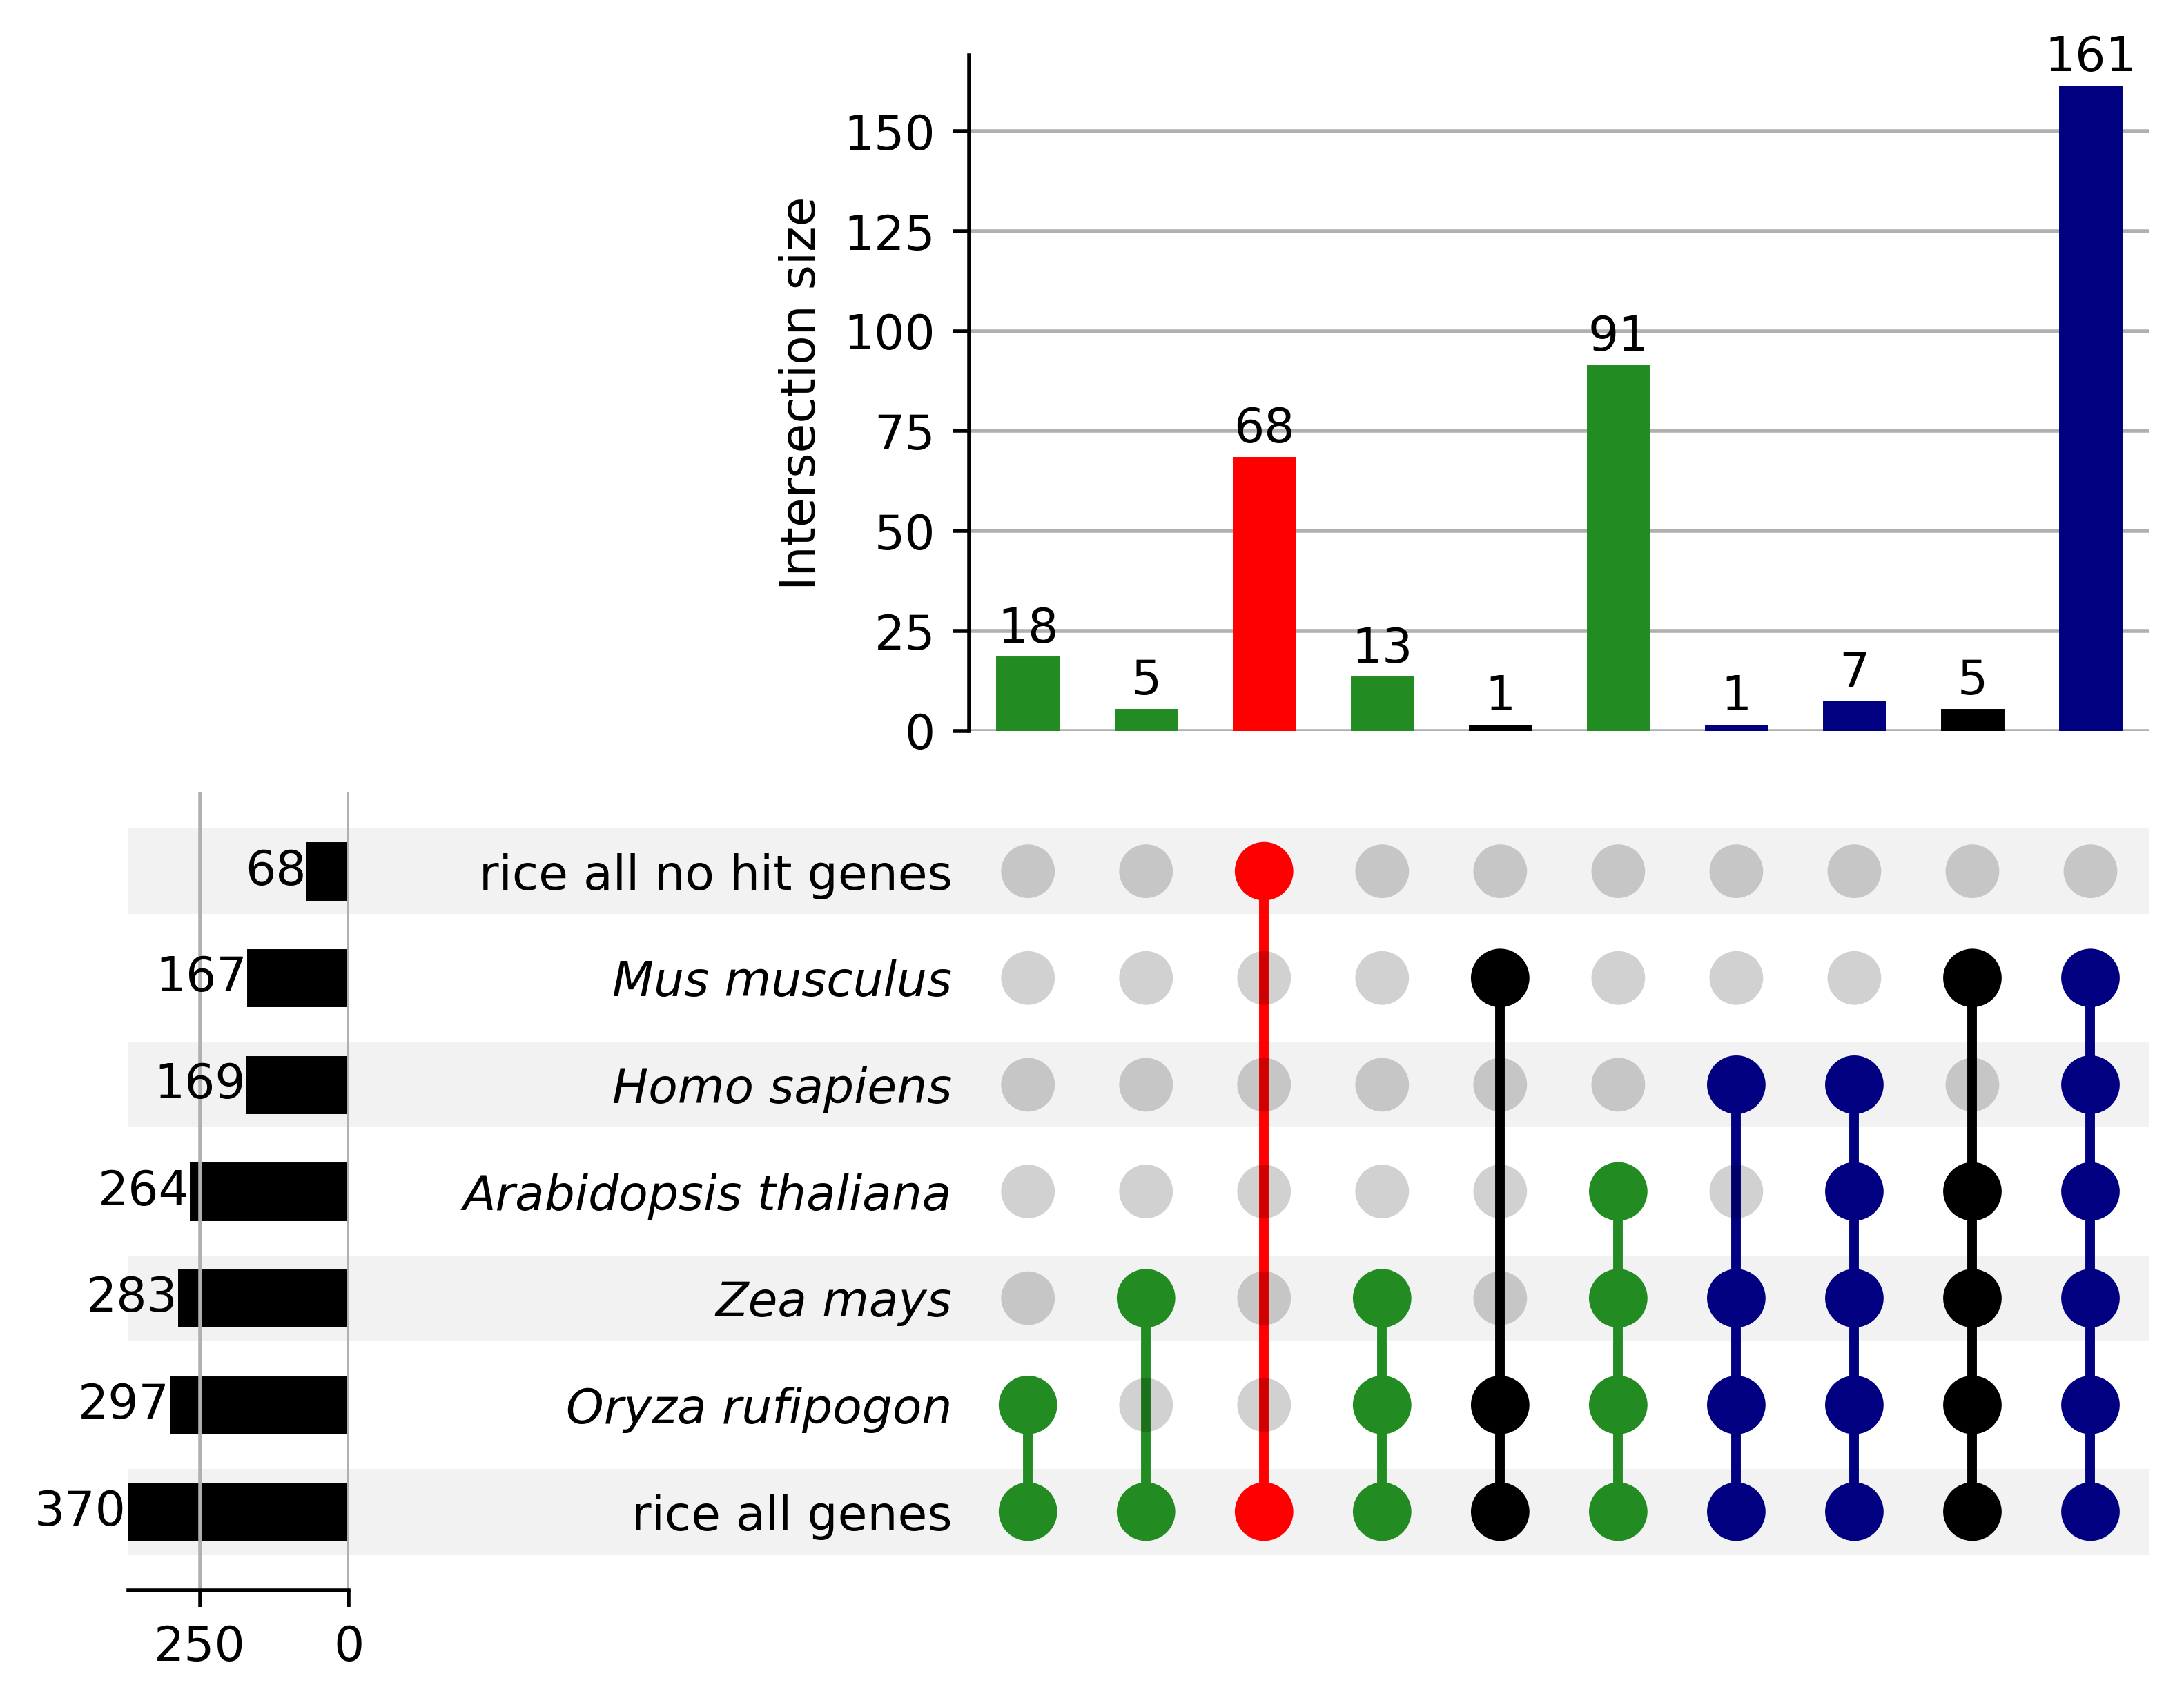

In [21]:
upset_plot = UpSet(
    upset_data,
    orientation='horizontal',
    show_counts="{:d}",
    subset_size='count',
    include_empty_subsets = False
)

upset_plot.style_subsets(present="Homo sapiens", 
                         facecolor="navy"
                         )

upset_plot.style_subsets(absent=["Homo sapiens", "Mus musculus"], 
                         facecolor="forestgreen"
                         )

upset_plot.style_subsets(absent=["Homo sapiens", "Mus musculus", "Arabidopsis thaliana", "Zea mays", "Oryza rufipogon"], 
                         facecolor="red"
                         )

fig = plt.figure(figsize=(14, 8), dpi=500)
axes = upset_plot.plot(fig=fig)

# Italicize binomial names; leave non-scientific labels upright
non_scientific = {"rice all genes", "rice all no hit genes"}
for tick in axes["matrix"].get_yticklabels():
    if tick.get_text() not in non_scientific:
        tick.set_fontstyle("italic")

plt.show()

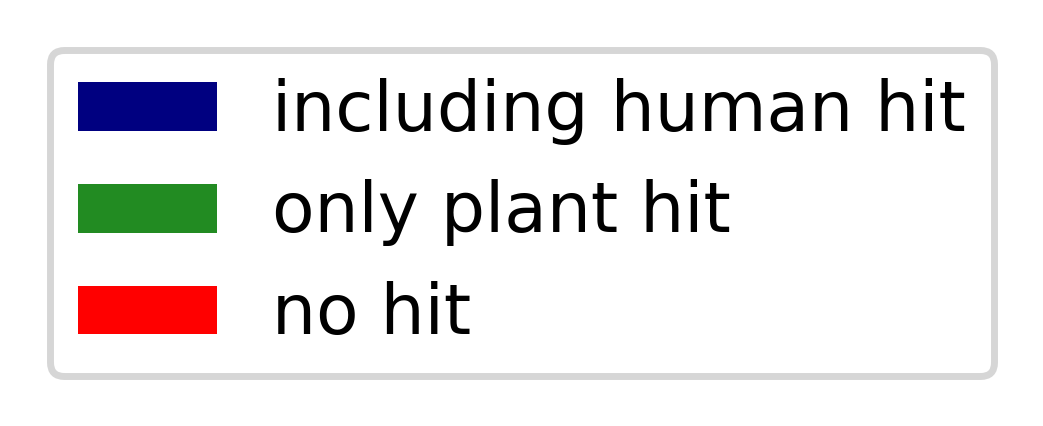

In [22]:
# Create legend independently
legend_elements = [
    Patch(facecolor="navy", label="including human hit"),
    Patch(facecolor='forestgreen', label='only plant hit'),
    Patch(facecolor='red', label='no hit')
]

fig_leg = plt.figure(figsize=(1.5, 0.5), dpi=500)
ax_leg = fig_leg.add_subplot(111)
ax_leg.legend(handles=legend_elements, loc='center')
ax_leg.axis('off') 
plt.show()
# fig_leg.savefig('legend.png', bbox_inches='tight')